In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
%matplotlib inline

In [2]:
cols = ['CreditScore','Geography','Gender','Age','Tenure',
        'Balance','NumOfProducts','IsActiveMember','EstimatedSalary','Exited']

churn = pd.read_csv(
    r"C:\\Users\\LENOVO\\Downloads\\archive (2)\\Churn_Modelling.csv",
    usecols=cols
)
churn.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,79084.10,0


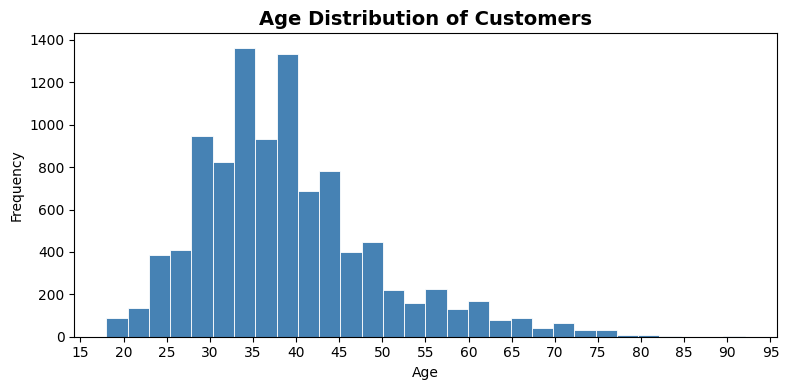

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(churn['Age'], bins=30, color='steelblue', edgecolor='white', linewidth=0.6)

ax.set_title('Age Distribution of Customers', fontsize=14, fontweight='bold')
ax.set_xlabel('Age')
ax.set_ylabel('Frequency')
ax.xaxis.set_major_locator(ticker.MultipleLocator(5))

plt.tight_layout()
plt.show()

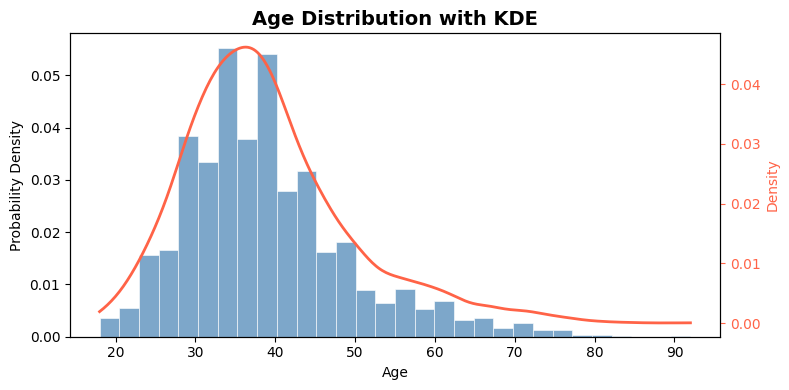

In [4]:
from scipy.stats import gaussian_kde

age_vals = churn['Age'].dropna().values
kde = gaussian_kde(age_vals, bw_method='scott')
x_range = np.linspace(age_vals.min(), age_vals.max(), 300)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(age_vals, bins=30, density=True,         # density=True scales y to probability
        color='steelblue', edgecolor='white', linewidth=0.6, alpha=0.7)
ax2 = ax.twinx()
ax2.plot(x_range, kde(x_range), color='tomato', linewidth=2, label='KDE')
ax2.set_ylabel('Density', color='tomato')
ax2.tick_params(axis='y', colors='tomato')

ax.set_title('Age Distribution with KDE', fontsize=14, fontweight='bold')
ax.set_xlabel('Age')
ax.set_ylabel('Probability Density')

plt.tight_layout()
plt.show()

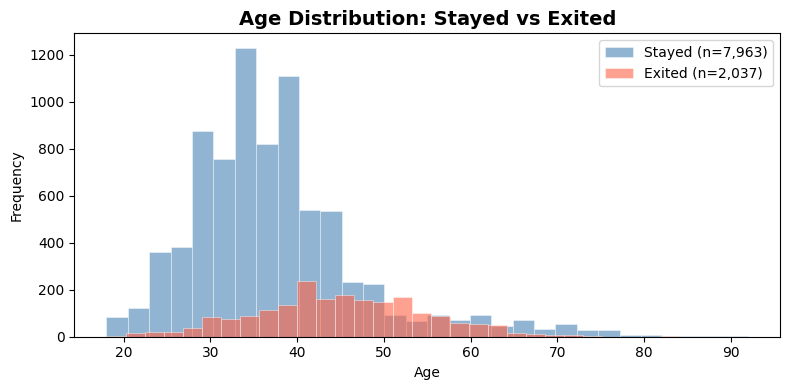

In [5]:
stayed = churn.loc[churn['Exited'] == 0, 'Age']
exited = churn.loc[churn['Exited'] == 1, 'Age']

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(stayed, bins=30, alpha=0.6, color='steelblue', edgecolor='white',
        linewidth=0.5, label=f'Stayed (n={len(stayed):,})')
ax.hist(exited, bins=30, alpha=0.6, color='tomato', edgecolor='white',
        linewidth=0.5, label=f'Exited (n={len(exited):,})')

ax.set_title('Age Distribution: Stayed vs Exited', fontsize=14, fontweight='bold')
ax.set_xlabel('Age')
ax.set_ylabel('Frequency')
ax.legend()

plt.tight_layout()
plt.show()

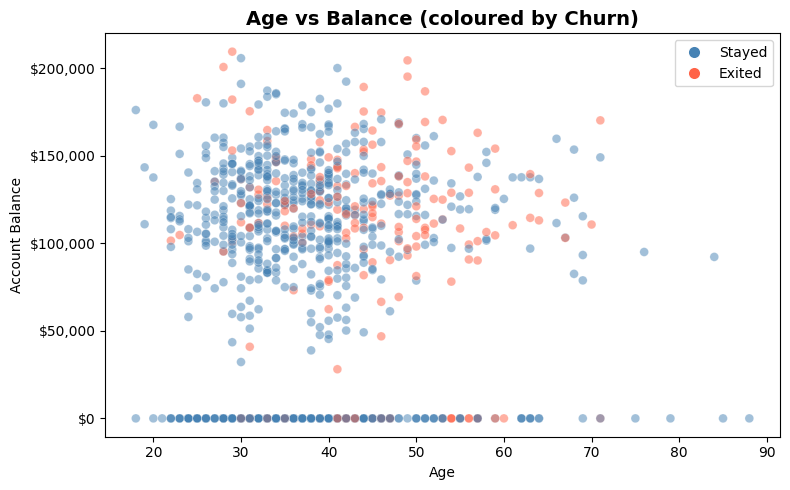

In [6]:
sample = churn.sample(1000, random_state=42)   # sample to avoid over-plotting

fig, ax = plt.subplots(figsize=(8, 5))
scatter = ax.scatter(sample['Age'], sample['Balance'],
                     c=sample['Exited'].map({0: 'steelblue', 1: 'tomato'}),
                     alpha=0.5, edgecolors='white', linewidths=0.3, s=40)

# Manual legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='steelblue',
           markersize=9, label='Stayed'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='tomato',
           markersize=9, label='Exited'),
]
ax.legend(handles=legend_elements)

ax.set_title('Age vs Balance (coloured by Churn)', fontsize=14, fontweight='bold')
ax.set_xlabel('Age')
ax.set_ylabel('Account Balance')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

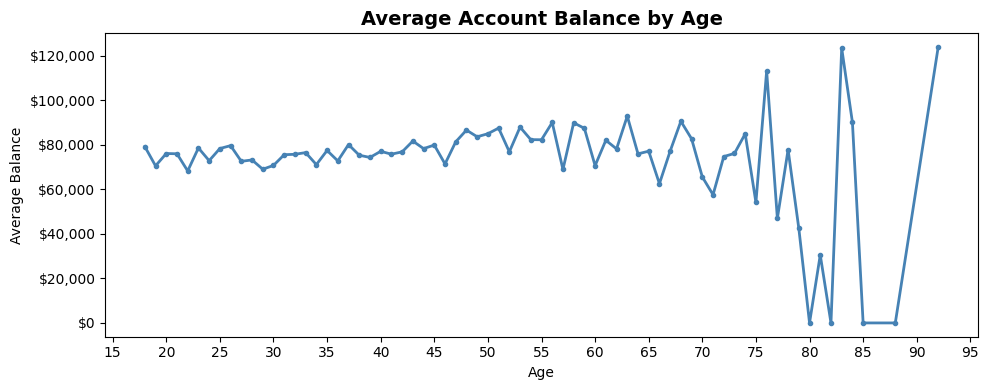

In [7]:
avg_balance = (churn.groupby('Age')['Balance']
                .mean()
                .reset_index()
                .rename(columns={'Balance': 'AvgBalance'}))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(avg_balance['Age'], avg_balance['AvgBalance'],
        color='steelblue', linewidth=2, marker='o', markersize=3)

ax.set_title('Average Account Balance by Age', fontsize=14, fontweight='bold')
ax.set_xlabel('Age')
ax.set_ylabel('Average Balance')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.xaxis.set_major_locator(ticker.MultipleLocator(5))

plt.tight_layout()
plt.show()

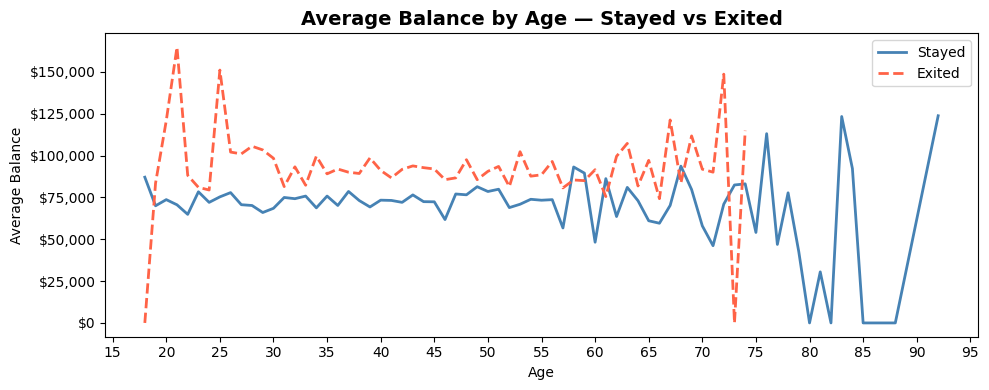

In [8]:
avg_by_exit = (churn.groupby(['Age', 'Exited'])['Balance']
                .mean()
                .unstack()
                .rename(columns={0: 'Stayed', 1: 'Exited'}))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(avg_by_exit.index, avg_by_exit['Stayed'],
        color='steelblue', linewidth=2, label='Stayed')
ax.plot(avg_by_exit.index, avg_by_exit['Exited'],
        color='tomato', linewidth=2, linestyle='--', label='Exited')

ax.set_title('Average Balance by Age — Stayed vs Exited', fontsize=14, fontweight='bold')
ax.set_xlabel('Age')
ax.set_ylabel('Average Balance')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.xaxis.set_major_locator(ticker.MultipleLocator(5))
ax.legend()

plt.tight_layout()
plt.show()

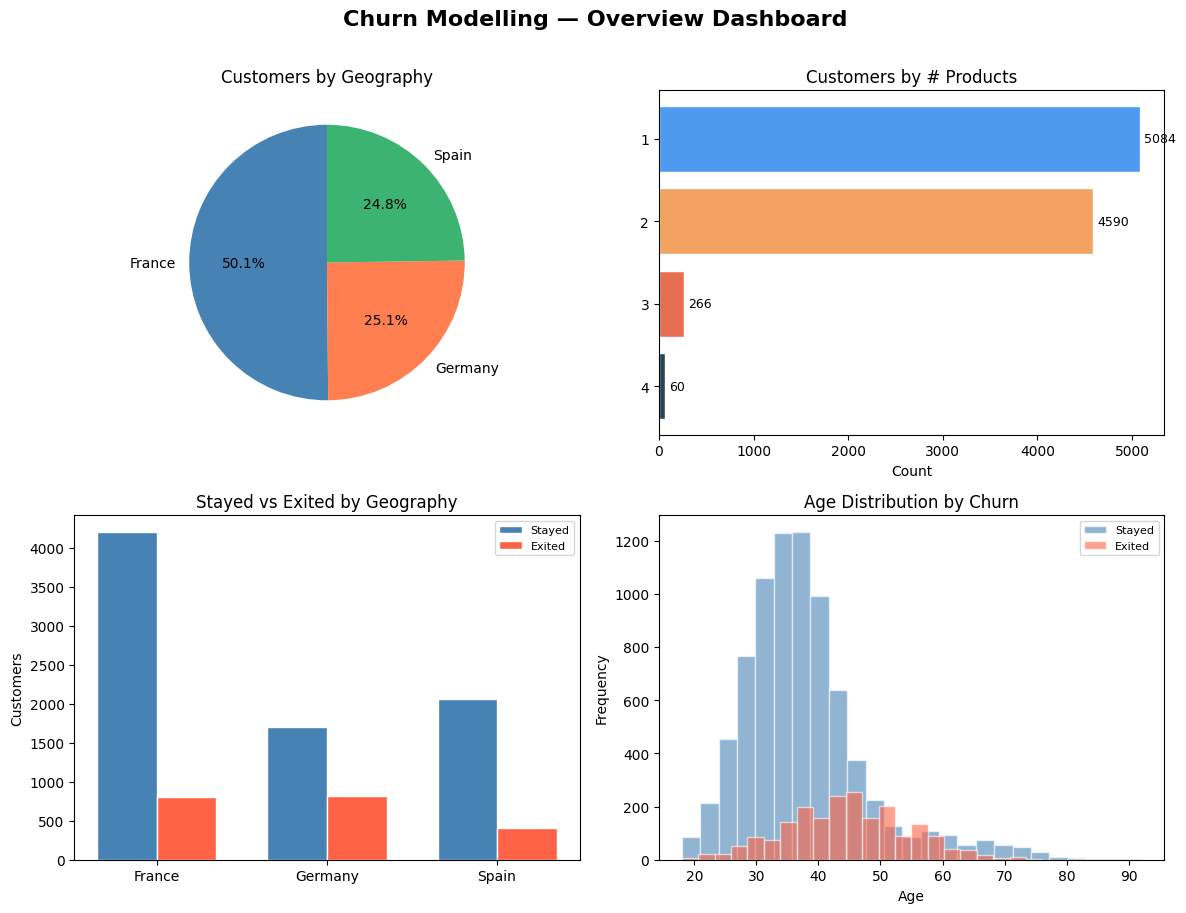

In [9]:
geo_counts  = churn['Geography'].value_counts()
prod_counts = churn['NumOfProducts'].value_counts().sort_index()
group       = churn.groupby(['Geography', 'Exited']).size().unstack(fill_value=0)
group.columns = ['Stayed', 'Exited']
countries   = group.index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle('Churn Modelling — Overview Dashboard', fontsize=16, fontweight='bold', y=1.01)

# ── Top-left: pie chart ──────────────────────────────────────────────
ax = axes[0, 0]
ax.pie(geo_counts.values, labels=geo_counts.index,
       colors=['steelblue', 'coral', 'mediumseagreen'],
       autopct='%1.1f%%', startangle=90)
ax.set_title('Customers by Geography')

# ── Top-right: horizontal bar ────────────────────────────────────────
ax = axes[0, 1]
bars = ax.barh(prod_counts.index.astype(str), prod_counts.values,
               color=['#4e9af1', '#f4a261', '#e76f51', '#264653'][:len(prod_counts)],
               edgecolor='white')
ax.bar_label(bars, fmt='%d', padding=3, fontsize=9)
ax.set_title('Customers by # Products')
ax.set_xlabel('Count')
ax.invert_yaxis()

# ── Bottom-left: grouped bar ─────────────────────────────────────────
ax = axes[1, 0]
x = np.arange(len(countries))
w = 0.35
b1 = ax.bar(x - w/2, group['Stayed'], w, label='Stayed', color='steelblue', edgecolor='white')
b2 = ax.bar(x + w/2, group['Exited'], w, label='Exited', color='tomato',    edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(countries)
ax.set_title('Stayed vs Exited by Geography')
ax.set_ylabel('Customers')
ax.legend(fontsize=8)

# ── Bottom-right: histogram ──────────────────────────────────────────
ax = axes[1, 1]
ax.hist(churn.loc[churn['Exited']==0, 'Age'], bins=25, alpha=0.6,
        color='steelblue', edgecolor='white', label='Stayed')
ax.hist(churn.loc[churn['Exited']==1, 'Age'], bins=25, alpha=0.6,
        color='tomato',    edgecolor='white', label='Exited')
ax.set_title('Age Distribution by Churn')
ax.set_xlabel('Age'); ax.set_ylabel('Frequency')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()